# **Phase 1: Environment Setup & Data Logisticst**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Libraries**

In [ ]:
# Install Streamlit and Localtunnel
!pip install -q streamlit
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 123.4 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 2s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [ ]:
# 1. General Utilities
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Google Colab & File Management
from google.colab import drive
drive.mount('/content/drive')

# 3. Deep Learning (TensorFlow & Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, Input, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications import ResNet50, VGG16 ,MobileNetV2 # Transfer Learning Models
from tensorflow.keras.optimizers import Adam

# 4. Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 5. Deployment
import streamlit as st

print("All libraries imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries imported successfully!


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_model.keras",   # مهم تغيري لـ keras
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# **Data Loading**

In [ ]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path configuration (Adjust the zip name if it's different)
zip_path = '/content/drive/MyDrive/archive.zip'  # أو (1)
extract_path = '/content/dataset/'

# 3. Extracting the zip file
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Done: Dataset extracted to /content/dataset/")
else:
    print("Error: Please make sure the zip file is in your Drive.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done: Dataset extracted to /content/dataset/


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if '.zip' in file:
            print(root + '/' + file)

/content/drive/MyDrive/archive.zip
/content/drive/MyDrive/archive (1).zip


In [ ]:
!ls /content

dataset  drive	sample_data


In [ ]:
# Check the contents of the extracted folder
!ls /content/dataset/

Celeb_V2


# **Phase 2: Data Preprocessing Pipeline (Conceptual)**

# **Image Data Augmentation (For Training)**

In [ ]:
# Create an instance for Training with Augmentation to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalization
    rotation_range=20,     # Random rotation
    width_shift_range=0.2, # Horizontal shift
    height_shift_range=0.2,# Vertical shift
    horizontal_flip=True,  # Mirroring images
    fill_mode='nearest'
)

# Create an instance for Validation and Testing (Only Rescaling, NO Augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# **Loading Data from Directoriest**

In [ ]:
print(os.listdir('/content'))
print(os.listdir('/content/dataset'))


['.config', 'dataset', 'drive', 'sample_data']
['Celeb_V2']


In [ ]:

zip_path = '/content/drive/MyDrive/archive.zip'  # أو (1)
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done ✅ Dataset extracted")

Done ✅ Dataset extracted


In [ ]:

print(os.listdir('/content/dataset'))

['Celeb_V2']


In [ ]:

print(os.listdir('/content/dataset/Celeb_V2'))

['Val', 'Train', 'Test']


# **Parameters**

In [ ]:
# Constants and Parameters
IMG_SIZE = (224, 224) # Match input size required for pretrained models (224x224)
BATCH_SIZE = 32
SEED = 123
BASE_PATH = '/content/dataset/Celeb_V2'

# **Generators**

In [ ]:
# Loading Data into Generators
# Training: with augmentation
# Validation/Test: only rescaling

#Train
print("\n📦 Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

#Validation
print("\n📊 Loading Validation Data...")
val_generator = test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=False
)

#Test
print("\n🧪 Loading Test Data...")
test_generator = test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=False

)

# Get class names for visualization
CLASS_NAMES = list(train_generator.class_indices.keys())
print(f"\n✅ Success! Classes: {CLASS_NAMES}")
print("\n📌 Class Mapping:", train_generator.class_indices)


📦 Loading Training Data...


NameError: name 'train_datagen' is not defined

# **Phase 3: Building the Models (CNN from Scratch)**

# **Build Model**

In [ ]:
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **COMPILE MODEL**

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ CNN Model Compiled Successfully")
model.summary()

✅ CNN Model Compiled Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

# **CALLBACKS**

In [ ]:
# Training Control
# EarlyStopping prevents overfitting by stopping training when validation loss stops improving
# ModelCheckpoint saves the best performing model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "cnn_best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

print("📌 Callbacks Ready")

📌 Callbacks Ready


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **TRAINING**

In [ ]:
# Model Training Phase
# Training CNN from scratch to learn deepfake features

EPOCHS = 3  # start small to avoid Colab limits

print(" Starting CNN Training...")

history_cnn = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

print("🎯 Training Finished")

 Starting CNN Training...
Epoch 1/3
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5202 - loss: 2.0381

2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1148s 449ms/step - accuracy: 0.5159 - loss: 0.9438 - val_accuracy: 0.4932 - val_loss: 0.8547
Epoch 2/3
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.5010 - loss: 0.6950

2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1124s 445ms/step - accuracy: 0.5012 - loss: 0.6952 - val_accuracy: 0.5036 - val_loss: 0.7463
Epoch 3/3
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.5014 - loss: 0.7140

2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1148s 454ms/step - accuracy: 0.4998 - loss: 0.6977 - val_accuracy: 0.5016 - val_loss: 0.6932
🎯 Training Finished


# **EVALUATION**

In [ ]:
# Evaluate CNN Model Performance on Test Data
print("📊 Evaluating CNN Model...")
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

#**Confusion Matrix CNN**

316/316 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step


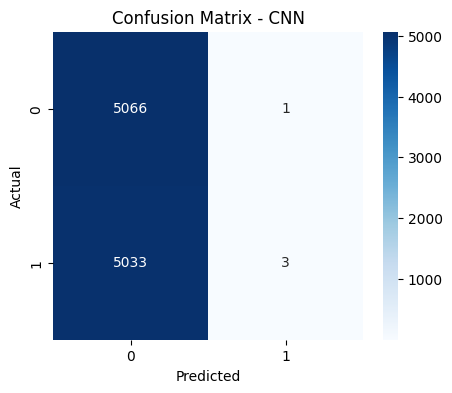

In [ ]:
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Save Results**

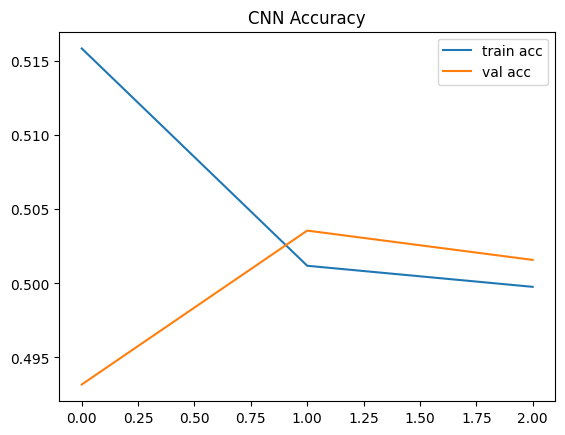

In [ ]:
cnn_results = {
    "accuracy": test_acc,
    "loss": test_loss
}
#history to gragh
plt.plot(history_cnn.history['accuracy'], label='train acc')
plt.plot(history_cnn.history['val_accuracy'], label='val acc')
plt.title("CNN Accuracy")
plt.legend()
plt.show()

# **Phase 4: Transfer Learning (MobileNetV2)**

# **STEP 1: Load MobileNetV2**

In [ ]:
# Transfer Learning using MobileNetV2
# We use pretrained ImageNet weights as feature extractor and remove the top classification layer

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("✅ Base Model Loaded (MobileNetV2)")

✅ Base Model Loaded (MobileNetV2)


# **STEP 2: Freeze Base Model**

In [ ]:
# Freeze all layers in the base model
# We only train the new classification head first (Feature Extraction phase)

base_model.trainable = False
print("🔒 Base Model Frozen")

🔒 Base Model Frozen


# **STEP 3: Build New Classifier Head**

In [ ]:
# Add custom classification head for binary classification (real vs fake)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

print("🧠 Transfer Learning Model Built")
model_tl.summary()

🧠 Transfer Learning Model Built


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **STEP 4: Compile Model**

In [ ]:
# Compile with binary crossentropy and Adam optimizer

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("⚙️ Model Compiled")

⚙️ Model Compiled


# **STEP 5: Training (Feature Extraction)**

In [ ]:
# Train only the new classification head while base model is frozen
# This is the feature extraction phase

print("🚀 Training Transfer Learning Model (Feature Extraction)...")

history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

print("🎯 Feature Extraction Done")

🚀 Training Transfer Learning Model (Feature Extraction)...
Epoch 1/5
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6152 - loss: 0.6520
Epoch 1: val_loss improved from None to 0.56583, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1050s 407ms/step - accuracy: 0.6416 - loss: 0.6266 - val_accuracy: 0.7028 - val_loss: 0.5658
Epoch 2/5
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6748 - loss: 0.5929
Epoch 2: val_loss improved from 0.56583 to 0.54352, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1022s 404ms/step - accuracy: 0.6798 - loss: 0.5883 - val_accuracy: 0.7217 - val_loss: 0.5435
Epoch 3/5
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6887 - loss: 0.5783
Epoch 3: val_loss improved from 0.54352 to 0.54245, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2526/2526 ━━━━━━━━

In [ ]:
print("📊 Last Training Accuracy:", history_tl.history['accuracy'][-1])
print("📊 Last Validation Accuracy:", history_tl.history['val_accuracy'][-1])

📊 Last Training Accuracy: 0.7030832171440125
📊 Last Validation Accuracy: 0.7354512810707092


In [ ]:
base_model.trainable = True

# Freeze bottom layers, unfreeze top 30%
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("🔓 Fine-tuning Enabled")

🔓 Fine-tuning Enabled


# **STEP 6:RECOMPILE (VERY IMPORTANT)**

In [ ]:
model_tl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_tl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,963,713 (7.49 MB)

 Non-trainable params: 458,368 (1.75 MB)

# **STEP 7 :FINE TUNING TRAINING**

In [ ]:
print("🔥 Fine-tuning Training...")

history_fine = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

🔥 Fine-tuning Training...
Epoch 1/5
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6800 - loss: 0.6454
Epoch 1: val_loss did not improve from 0.52214
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1088s 422ms/step - accuracy: 0.7365 - loss: 0.5260 - val_accuracy: 0.6767 - val_loss: 0.7007
Epoch 2/5
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8292 - loss: 0.3817
Epoch 2: val_loss improved from 0.52214 to 0.38513, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1040s 412ms/step - accuracy: 0.8417 - loss: 0.3602 - val_accuracy: 0.8191 - val_loss: 0.3851
Epoch 3/5
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8721 - loss: 0.2997
Epoch 3: val_loss improved from 0.38513 to 0.22135, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 1047s 414ms/step - accuracy: 0.8798 - loss: 0.2857 - val_accuracy: 0.9084 - val_loss: 0.2214
Epoch 4/5
2526

# **STEP 8: EVALUATION**

In [ ]:
print("📊 Evaluating Model...")

test_loss_tl, test_acc_tl = model_tl.evaluate(test_generator)

print(f"Accuracy: {test_acc_tl:.4f}")
print(f"Loss: {test_loss_tl:.4f}")

📊 Evaluating Model...
316/316 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.9240 - loss: 0.1829
Accuracy: 0.9240
Loss: 0.1829


# **STEP 9: Confusion Matrix TL**

316/316 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step


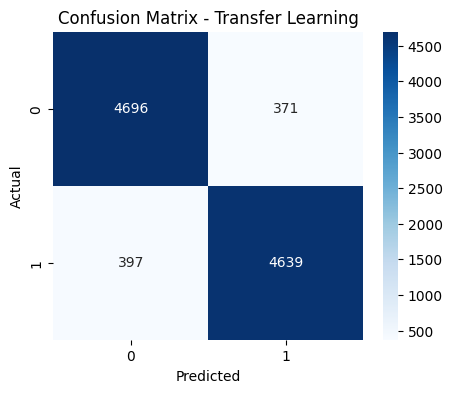

In [ ]:
y_pred = model_tl.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Transfer Learning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **STEP 10: SAVE RESULTS**

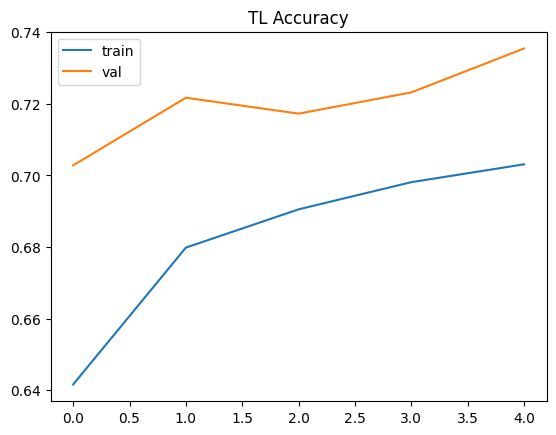

In [ ]:
tl_results = {
    "model": "MobileNetV2",
    "accuracy": test_acc_tl,
    "loss": test_loss_tl
}
#history to graph
plt.plot(history_tl.history['accuracy'], label='train')
plt.plot(history_tl.history['val_accuracy'], label='val')
plt.legend()
plt.title("TL Accuracy")
plt.show()

# **"FINAL COMPARISON"**

In [ ]:
print("FINAL COMPARISON")

print("CNN Accuracy:", test_acc_cnn)
print("TL Accuracy :", test_acc_tl)

# **SAVE MODEL**

In [ ]:
model_tl.save("/content/drive/MyDrive/final_model.keras")

In [ ]:
from google.colab import files

files.download('/content/drive/MyDrive/final_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>